<a href="https://colab.research.google.com/github/jRicardo2003/JoseMiguel2507232022/blob/main/Notebooks/agrupacionClaveB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
url ="https://raw.githubusercontent.com/jRicardo2003/JoseMiguel2507232022/refs/heads/main/data/clave_B_agrupacion.csv"
df = pd.read_csv(url)
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,B-R0196,35,962,3.08,42.02,4.95,6,1
1,B-R0031,18,534,3.36,47.80,6.81,2,14
2,B-R0059,24,408,2.24,68.25,5.75,0,1
3,B-R0204,48,1250,4.52,61.06,2.54,12,6
4,B-R0103,35,1043,6.96,78.62,7.37,0,1


Seleccionar variables adecuadas para clustering

In [6]:
print(df.columns)

Index(['registro_id', 'edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio',
       'satisfaccion', 'reclamos', 'antiguedad_meses'],
      dtype='object')


In [7]:
variables_cluster = df[[
    'edad',
    'ingresos',
    'frecuencia_uso',
    'gasto_promedio',
    'satisfaccion',
    'reclamos',
    'antiguedad_meses'
]]

variables_cluster.head()

#se seleccionaron estas variables porque son numéricas, relevantes para segmentar clientes,  útiles para identificar patrones de comportamiento


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,35,962,3.08,42.02,4.95,6,1
1,18,534,3.36,47.80,6.81,2,14
2,24,408,2.24,68.25,5.75,0,1
3,48,1250,4.52,61.06,2.54,12,6
4,35,1043,6.96,78.62,7.37,0,1


Normalizar o escalar los datos correctamente


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(variables_cluster)

In [9]:
scaled_data

array([[-0.06678665,  0.03725086, -0.76312486, ..., -1.04440172,
         1.77335929, -1.24584129],
       [-1.76984617, -0.96429215, -0.66932866, ..., -0.05893946,
        -0.17712754, -0.30332719],
       [-1.16876634, -1.25913892, -1.04451346, ..., -0.62054698,
        -1.15237096, -1.24584129],
       ...,
       [ 1.33573296,  0.35315811,  1.27024278, ...,  1.14374836,
        -1.15237096,  2.30671186],
       [-0.96840639, -1.23807844, -0.06970295, ..., -0.39272506,
         0.79811587, -0.7383337 ],
       [-0.06678665,  0.00683016, -0.4113891 , ...,  1.08017015,
        -1.15237096,  0.27668149]])

Aplicar el método del codo o una técnica para seleccionar el número de grupos


In [11]:
variables_cluster.isnull().sum()

,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,1
reclamos,0
antiguedad_meses,0


In [12]:
variables_cluster = variables_cluster.dropna()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(variables_cluster)

In [14]:
from sklearn.cluster import KMeans

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

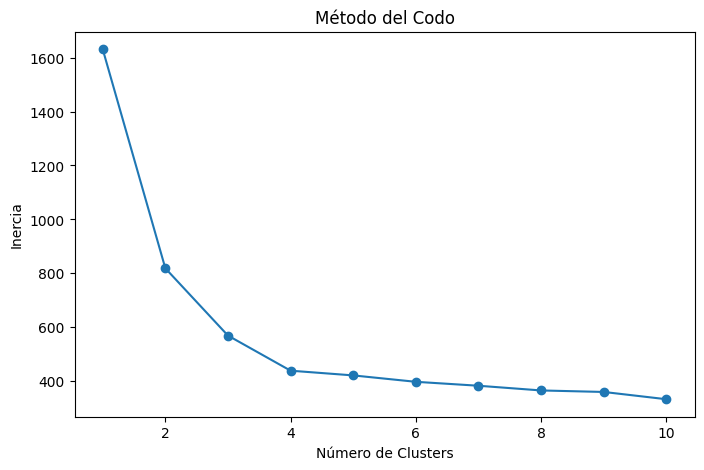

In [16]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')

plt.show()

Aplicar K-Means u otro algoritmo de agrupación

In [17]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

Agregar la columna del grupo o cluster al dataset original

In [19]:
df_cluster = df[[
    'edad',
    'ingresos',
    'frecuencia_uso',
    'gasto_promedio',
    'satisfaccion',
    'reclamos',
    'antiguedad_meses'
]].dropna()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_cluster)

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

In [22]:
df_cluster['cluster'] = clusters

In [23]:
df_cluster.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,35,962,3.08,42.02,4.95,6,1,3
1,18,534,3.36,47.80,6.81,2,14,0
2,24,408,2.24,68.25,5.75,0,1,0
3,48,1250,4.52,61.06,2.54,12,6,3
4,35,1043,6.96,78.62,7.37,0,1,1


Visualizar los grupos mediante gráficos

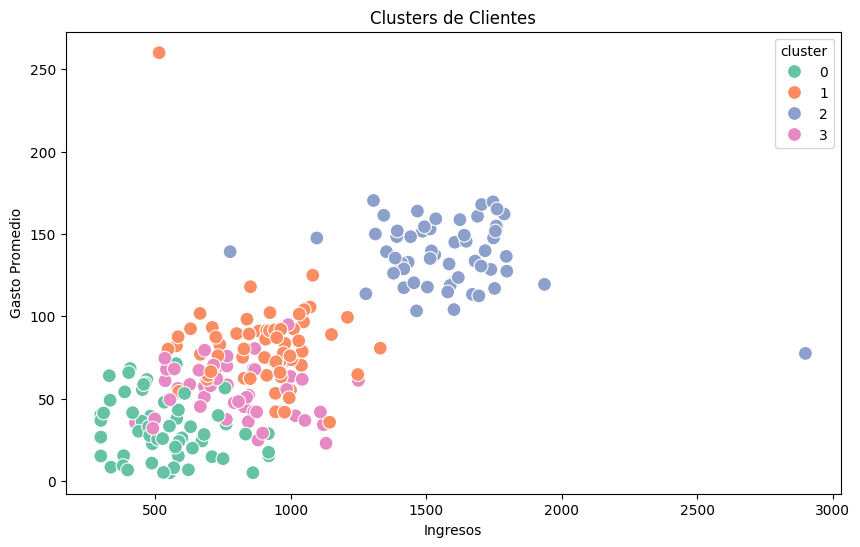

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_cluster,
    x='ingresos',
    y='gasto_promedio',
    hue='cluster',
    palette='Set2',
    s=100
)

plt.title('Clusters de Clientes')
plt.xlabel('Ingresos')
plt.ylabel('Gasto Promedio')

plt.show()

In [25]:
df_cluster.groupby('cluster').mean(numeric_only=True)

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,24.220339,533.745763,1.965763,31.420847,5.951695,3.067797,6.932203
1,33.727273,896.409091,6.366818,81.448333,8.137727,1.106061,17.636364
2,47.500000,1572.714286,8.880714,137.553929,8.748036,0.625000,37.053571
3,38.307692,795.653846,4.100385,54.264038,4.510000,5.038462,11.134615


Interpretar cada grupo encontrado


In [ ]:
## Cluster 0 — Clientes de Bajo Consumo

Este grupo está compuesto por clientes jóvenes con ingresos bajos y bajo gasto promedio.

Características principales:
- Menor frecuencia de uso.
- Menor consumo general.
- Nivel de satisfacción medio.
- Cantidad moderada de reclamos.

Estos clientes representan consumidores ocasionales con bajo nivel de fidelización.

---

## Cluster 1 — Clientes Frecuentes y Satisfechos

Este grupo presenta ingresos medios y una alta frecuencia de uso.

Características principales:
- Alto gasto promedio.
- Buen nivel de satisfacción.
- Pocos reclamos.
- Mayor antigüedad dentro de la empresa.

Estos clientes representan consumidores frecuentes y relativamente leales.

---

## Cluster 2 — Clientes Premium

Este cluster corresponde a clientes con mayores ingresos y el gasto promedio más alto.

Características principales:
- Mayor frecuencia de uso.
- Nivel de satisfacción elevado.
- Muy pocos reclamos.
- Alta antigüedad como clientes.

Este grupo representa los clientes más valiosos para la empresa.

---

## Cluster 3 — Clientes con Riesgo de Insatisfacción

Este grupo presenta ingresos medios, pero niveles de satisfacción más bajos.

Características principales:
- Mayor cantidad de reclamos.
- Gasto moderado.
- Frecuencia de uso intermedia.
- Nivel bajo de satisfacción.

Estos clientes podrían abandonar la empresa si no se mejoran los servicios o la atención brindada.

Proponer acciones de negocio para cada grupo

In [ ]:
# Acciones de Negocio para Cada Cluster

## Cluster 0
- Crear promociones y descuentos para incentivar mayor consumo.
- Implementar estrategias de fidelización para aumentar frecuencia de uso.

---

## Cluster 1
- Mantener programas de recompensas y beneficios.
- Ofrecer promociones personalizadas para fortalecer la lealtad.

---

## Cluster 2
- Diseñar servicios premium exclusivos.
- Priorizar atención personalizada y beneficios VIP.
- Implementar estrategias de retención de clientes de alto valor.

---

## Cluster 3
- Mejorar tiempos de respuesta y atención al cliente.
- Analizar causas de reclamos frecuentes.
- Implementar campañas de recuperación de clientes insatisfechos.